# **Домашняя работа: прогнозирование заработной платы и кластеризация типов движений**

### **Постановка задачи:**

В этой работе две части:

*   В первой части вам предстоит построить алгоритм на основе бустинга для прогнозирования зарплаты
*   Во второй части вам предстоит кластеризовать типы движений по имеющимся данным с акселерометров и гироскопов




# **Часть 1. Прогнозирование заработной платы при помощи бустинга**

**Количество баллов:** 7

## **Постановка задачи:**

Данные выгружены и лежат в файле `ds_salary.csv`. Вам доступны описания признаков и значения целевой переменной.

**Ваша задача:** построение модели бустинга и оценка данной модели.

## **Описание даных**

- work_year: год, в который взяты данные;
- experience_level: уровень опыта, кодируемый как SE, MI EN или EX
- employment_type: тип занятости (FT, PT, CT, FL)
- job_title: название рабочей позиции в компании;
- salary: зараплата на позиции;
- salary_currency: валюта в которой начисляют зарплату;
- employee_residence: страна или регион проживания сотрудника
- remote_ratio: процент удаленки, предлагаемый в компании (0, 50, 100)
- company_location: местоположение компании
- company_size: размер компании, оцененный как S, M, L
- salary_in_usd: целевая переменная


Как всегда, загрузим набор данных.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("https://github.com/hse-ds/iad-intro-ds/raw/refs/heads/master/2023/homeworks/hw-08-boosting/ds_salaries.csv")

## **Задание 1 (0.3 балла)**

Вам даны описания переменных. Проверьте, что категориальные признаки, категории которых перечислены, не имеют ошибочных значений. Для этого:

- Напишите цикл, пробегающий по выбранным признакам и оценивающий, что в них нет лишних значений;

In [ ]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [ ]:
col_cat = {'experience_level': ['SE', 'MI', 'EN', 'EX'], 'employment_type': ['FT', 'PT', 'CT', 'FL'], 'remote_ratio': [0, 50, 100], 'company_size': ['S', 'M', 'L']}

In [ ]:
for col, value in col_cat.items():
  wrong_values = df[~df[col].isin(value)][col].unique()
  if len(wrong_values) > 0:
    print(f'В колокне {col} есть лишние значения')
  else:
    print(f'В колокне {col} нет лишних значений')

В колокне experience_level нет лишних значений
В колокне employment_type нет лишних значений
В колокне remote_ratio нет лишних значений
В колокне company_size нет лишних значений


## **Задание 2 (0.3 балла)**

Проведите базовые шаги оценки качества данных.
- Есть есть проблемы, устраните их;
- Если нет проблем, кратко опишите это.

In [ ]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


In [ ]:
df.describe(include='object')

,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,3755,3755,3755,3755,3755,3755,3755
unique,4,4,93,20,78,72,3
top,SE,FT,Data Engineer,USD,US,US,M
freq,2516,3718,1040,3224,3004,3040,3153


In [ ]:
df.isna().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [ ]:
df.duplicated().sum()

1171

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [ ]:
df['work_year'].unique() # тут посмотрела что нет нереального года(2026 или 1600 например)

array([2023, 2022, 2020, 2021])

In [ ]:
df[df['salary'] <= 0] # проверила есть ли в зп нулевые или отрицательные значения(вряд ли кто-то доплачивает за возможность работать)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size


In [ ]:
df[df['salary_in_usd'] <= 0] # аналогично комментарию выше

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size


Из проблем были найдены и удалены только дубликаты, остальное все в норме

## **Задание 3 (0.3 балла)**

Вернитесь к описанию признаков.
- Проверьте, все ли признаки соответствуют постановке задачи? Если есть лишние признаки, удалите их и обоснуйте удаление, если нет, сделайте вывод о релевантности (достаточно в одну-две строки)
- Зафиксируйте, в каких признаках много категорий.

In [ ]:
unique_counts = {col: df[col].nunique() for col in df.columns}
for feature, count in unique_counts.items():
  print(f'{feature} - {count}')

work_year - 4
experience_level - 4
employment_type - 4
job_title - 93
salary - 815
salary_currency - 20
salary_in_usd - 1035
employee_residence - 78
remote_ratio - 3
company_location - 72
company_size - 3


Из категориальных признаков много уникальных значений в job_title, employee_residence, company_location, но кажется что все они могут быть важны. Я бы конечно хотела удалить salary(зп в местной валюте) и salary_currency, тк модель может запомнить коэфициент на который можно умножить зп что б перевести ее в $(получится жирная подсказка), но тк далее есть задание обучить модель только на непрерывных признаках, а удалив salary, из непрерывных останется разве что год, в тоже время удалив только salary_currency, смысл в salary вообще пропадает, поэтому я решила оставить эти 2 признака.

## **Задание 4 (0.2 балла)**

Разделите выборку на train, test (80%, 20%).

In [ ]:
X = df.drop(columns='salary_in_usd').copy()
y = df['salary_in_usd'].copy()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

## **Задание 5 (0.3 балла)**

Будем проверять два сценария. Первый — построение модели только на непрерывных признаках, а второй — построение с категориальными. В этом задании подготовьте всё, чтобы проверить валидность обоих сценариев. А именно:

- Выделите данные для тренировки и теста для непрерывных признаков
- Выделите данные для тренировки и теста для непрерывных + категориальных признаков, пока ничего не кодируйте.

In [ ]:
X_train.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size
406,2023,EN,FT,Research Engineer,125000,USD,US,0,US,M
1365,2023,SE,FT,ML Engineer,150000,USD,US,0,US,M
3318,2022,SE,FT,Data Scientist,205300,USD,US,0,US,L
2514,2022,SE,FT,Data Engineer,97000,USD,US,100,US,M
2975,2022,EN,FT,BI Data Analyst,32400,BRL,BR,100,BR,L


In [ ]:
X_train_continuous = X_train[['work_year', 'salary']].copy()
X_test_continuous = X_test[['work_year', 'salary']].copy()

## **Задание 6 (0.2 балла)**

- Обучите модель линейной регресии на числовых признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

Полагаю что тут не числовые, а непрерывные признаки, тк в задании 5 мы делили датасет именно на непрерывные и категориальные+непрерывные

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error as mape, mean_squared_error as mse

model_linear = LinearRegression()
model_linear.fit(X_train_continuous, y_train)
pred_linear = model_linear.predict(X_test_continuous)
mape_linear = mape(y_test, pred_linear)
rmse = np.sqrt(mse(y_test, pred_linear))
print(f'mape - {mape_linear}, rmse - {rmse}')

mape - 0.9195034639375431, rmse - 67757.58343205306


MAPE ~92%, на 92 процента в среднем наша модель ошибается, в числах на ~67800 $, получается очень плохая модель.

## **Задание 8 (0.2 балла)**

- Обучите модель бустинга (любую из трех библиотек catboost, xgboost, lightgbm) с гиперпараметрами по умолчанию на непрерывных признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

In [ ]:
!pip install catboost -q
from catboost import CatBoostRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.2 MB/s eta 0:00:00


In [ ]:
model_cal = CatBoostRegressor(verbose=0)
model_cal.fit(X_train_continuous, y_train)
pred_cat = model_cal.predict(X_test_continuous)
mape_cat = mape(y_test, pred_cat)
rmse = np.sqrt(mse(y_test, pred_cat))
print(f'mape - {mape_cat}, rmse - {rmse}')

mape - 0.2899136145675339, rmse - 25652.13219245676


Качество намного лучше чем у линейной регрессии, 29% ошибки

## **Задание 9 (0.8 балла)**

Теперь подключим категориальные признаки. Но попроубем разные стратегии предобработки.

**1:**
- Предобработайте категориальные признаки при помощи OHE
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**2:**
- Предобработайте категориальные признаки при помощи LabelEncoding
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**3:**
- Предобработайте категориальные признаки при помощи MeanTargetEnc
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

Сделайте выводы по построениям 1-3. Выберите лучшую модель и дальше поработайте с ней.

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [ ]:
cols_categorial = ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_enc = ohe.fit_transform(X_train[cols_categorial])
X_test_enc = ohe.transform(X_test[cols_categorial])
cols_numerical = ['work_year', 'salary']
ohe_columns = ohe.get_feature_names_out(cols_categorial)
X_train_enc_df = pd.DataFrame(X_train_enc, columns=ohe_columns, index=X_train.index)
X_test_enc_df = pd.DataFrame(X_test_enc, columns=ohe_columns, index=X_test.index)

X_train_enc = pd.concat([X_train_enc_df, X_train[cols_numerical]], axis=1)
X_test_enc = pd.concat([X_test_enc_df, X_test[cols_numerical]], axis=1)

In [ ]:
model_lin_enc = LinearRegression()
model_lin_enc.fit(X_train_enc, y_train)
pred_lin_enc = model_lin_enc.predict(X_test_enc)
mape_lin = mape(y_test, pred_lin_enc)
rmse_lin = np.sqrt(mse(y_test, pred_lin_enc))

model_cat_enc = CatBoostRegressor(verbose=0)
model_cat_enc.fit(X_train_enc, y_train)
pred_cat_enc = model_cat_enc.predict(X_test_enc)
mape_cat = mape(y_test, pred_cat_enc)
rmse_cat = np.sqrt(mse(y_test, pred_cat_enc))

print('OHE:')
print(f'Метрики линейной модели: mape - {mape_lin}, rmse - {rmse_lin}')
print(f'Метрики катбуста: mape - {mape_cat}, rmse - {rmse_cat}')

OHE:
Метрики линейной модели: mape - 0.7415536511460142, rmse - 59744.779392232136
Метрики катбуста: mape - 0.053505166776899385, rmse - 14511.175130110089


In [ ]:
X_train_le, X_test_le = X_train.copy(), X_test.copy()

X_train_le = X_train[cols_categorial].apply(LabelEncoder().fit_transform)
X_test_le = X_test[cols_categorial].apply(LabelEncoder().fit_transform)

In [ ]:
X_train_le = pd.concat([X_train_le, X_train[cols_numerical]], axis=1)
X_test_le = pd.concat([X_test_le, X_test[cols_numerical]], axis=1)

In [ ]:
model_lin_le = LinearRegression()
model_lin_le.fit(X_train_le, y_train)
pred_lin_le = model_lin_le.predict(X_test_le)
mape_lin_le = mape(y_test, pred_lin_le)
rmse_lin_le = np.sqrt(mse(y_test, pred_lin_le))

model_cat_le = CatBoostRegressor(verbose=0)
model_cat_le.fit(X_train_le, y_train)
pred_cat_le = model_cat_le.predict(X_test_le)
mape_cat_le = mape(y_test, pred_cat_le)
rmse_cat_le = np.sqrt(mse(y_test, pred_cat_le))

print('LabelEncoder:')
print(f'Метрики линейной модели: mape - {mape_lin_le}, rmse - {rmse_lin_le}')
print(f'Метрики катбуста: mape - {mape_cat_le}, rmse - {rmse_cat_le}')

LabelEncoder:
Метрики линейной модели: mape - 0.4776051091750725, rmse - 77282.43059087239
Метрики катбуста: mape - 0.2706521286197429, rmse - 48511.877324780566


In [ ]:
!pip install category_encoders -q
from category_encoders.target_encoder import TargetEncoder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.1 MB/s eta 0:00:00


In [ ]:
mean_enc = TargetEncoder(cols=cols_categorial)
X_train_mean = mean_enc.fit_transform(X_train, y_train)
X_test_mean = mean_enc.transform(X_test)

In [ ]:
X_train_mean.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size
406,2023,74306.886562,135534.009309,153333.542676,125000,149176.024619,154436.916395,144733.829676,153053.255933,142583.776628
1365,2023,154587.668513,135534.009309,143214.759007,150000,149176.024619,154436.916395,144733.829676,153053.255933,142583.776628
3318,2022,154587.668513,135534.009309,135236.185819,205300,149176.024619,154436.916395,144733.829676,153053.255933,111560.150641
2514,2022,154587.668513,135534.009309,141819.902041,97000,149176.024619,154436.916395,133239.086687,153053.255933,142583.776628
2975,2022,74306.886562,135534.009309,115564.914873,32400,110557.120838,105040.852181,133239.086687,104669.831191,111560.150641


In [ ]:
model_lin_mean = LinearRegression()
model_lin_mean.fit(X_train_mean, y_train)
pred_lin_mean = model_lin_mean.predict(X_test_mean)
mape_lin_mean = mape(y_test, pred_lin_mean)
rmse_lin_mean = np.sqrt(mse(y_test, pred_lin_mean))

model_cat_mean = CatBoostRegressor(verbose=0)
model_cat_mean.fit(X_train_mean, y_train)
pred_cat_mean = model_cat_mean.predict(X_test_mean)
mape_cat_mean = mape(y_test, pred_cat_mean)
rmse_cat_mean = np.sqrt(mse(y_test, pred_cat_mean))

print('MeanTargetEnc:')
print(f'Метрики линейной модели: mape - {mape_lin_mean}, rmse - {rmse_lin_mean}')
print(f'Метрики катбуста: mape - {mape_cat_mean}, rmse - {rmse_cat_mean}')

MeanTargetEnc:
Метрики линейной модели: mape - 0.5311698623124087, rmse - 55195.58652700066
Метрики катбуста: mape - 0.0547856106692368, rmse - 17190.009409992883


Лучшая модель - катбуст с OHE, метрики mape - 0.053505166776899385, rmse - 14511.175130110089.

## **Задание 10 (0.5 балла)**

Покажите, где ошибается ваша модель. Выведите топ 20 примеров с наибольшей ошибкой. Проанализируйте их. Какие выводы можно сделать? Что стоит изменить в данных чтобы улучшить качество модели?

In [ ]:
pred_cat_enc[:20]

array([170119.66091729, 191350.08330193, 176436.51354052,  12723.77526142,
       107345.94377505, 110273.26109578, 182868.57136891,  29592.61948009,
       131928.51991171,  94030.47303701, 105454.42177586, 228611.35703342,
       202946.35640719, 241528.61371878,  51333.38002691,  56525.45743503,
        79873.15474437,  46928.01975196,  75866.39850567, 155136.61106603])

In [ ]:
errors = np.abs(y_test - pred_cat_enc)

error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred_cat_enc,
    "Absolute Error": errors
})

top_errors = X_test.merge(error_df, left_index=True, right_index=True)

In [ ]:
top_errors.sort_values(by="Absolute Error", ascending=False).head(20)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size,Actual,Predicted,Absolute Error
2011,2022,MI,FT,Data Analyst,350000,GBP,GB,0,GB,M,430967,126567.216945,304399.783055
3624,2021,SE,FT,Data Scientist,180000,TRY,TR,50,TR,L,20171,66488.714243,46317.714243
3634,2021,MI,FT,Data Engineer,250000,TRY,TR,100,TR,M,28016,70039.220905,42023.220905
3754,2021,SE,FT,Data Science Manager,7000000,INR,IN,50,IN,L,94665,54575.832546,40089.167454
2358,2022,EN,FT,Data Scientist,6600000,HUF,HU,100,HU,M,17684,56521.791710,38837.791710
3667,2021,MI,FT,Data Scientist,420000,INR,IN,100,US,S,5679,40849.457553,35170.457553
3570,2021,MI,FT,Research Scientist,235000,CAD,CA,100,CA,L,187442,153973.385130,33468.614870
3682,2020,EN,FT,Data Engineer,4450000,JPY,JP,100,JP,S,41689,75005.938850,33316.938850
3541,2021,EX,FT,Director of Data Science,130000,EUR,IT,100,PL,L,153667,121370.142785,32296.857215
3683,2020,SE,FT,Big Data Engineer,100000,EUR,PL,100,GB,S,114047,84971.468069,29075.531931


1. Модель плохо предсказывает очень высокие и очень низкие зп
2. Так же ошибается при присутствии в salary_currency редких валют  
3. Большая ошибка в редких должностях: Research Scientist, Applied Machine Learning Scientist	 и т.д.  
Можно попробовать убрать salary, тк это я хотела сделать еще в 3 задании, тк вместе с валютой это равняется нашему таргету. Так же закодировать разные колонки разными способами, тк кодировать job_title с 93мя категориями ohe было смело.

## **Задание 11 (0.5 балла)**

Придумайте признаки для улучшения качества модели на основе предыдущего пункта. Как вам кажется какими признаками можно улучшить качетсво модели? Реализуйте признаки и проверьте улучшилось ли качество модели.

**Примечание:**
Полный балл за задание ставится даже при отсутствии улучшения качества модели, важно попробовать проверить свои гипотезы и сделать выводы.

In [ ]:
X_train_new = X_train.drop(columns=['salary'])
X_test_new = X_test.drop(columns=['salary'])
y_train = y_train.loc[X_train_new.index]
y_test = y_test.loc[X_test_new.index]

In [ ]:
df.describe(include='object')

,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,2584,2584,2584,2584,2584,2584,2584
unique,4,4,93,20,78,72,3
top,SE,FT,Data Engineer,USD,US,US,M
freq,1554,2547,598,2107,1893,1929,2028


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2067 entries, 406 to 3420
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           2067 non-null   int64 
 1   experience_level    2067 non-null   object
 2   employment_type     2067 non-null   object
 3   job_title           2067 non-null   object
 4   salary              2067 non-null   int64 
 5   salary_currency     2067 non-null   object
 6   employee_residence  2067 non-null   object
 7   remote_ratio        2067 non-null   int64 
 8   company_location    2067 non-null   object
 9   company_size        2067 non-null   object
dtypes: int64(3), object(7)
memory usage: 177.6+ KB


OHE закодирую experience_level, employment_type, remote_ratio и company_size, MeanTargetEnc - job_title и salary_currency, остальные OrdinalEncoder.

In [ ]:
col_ohe = ['experience_level', 'employment_type', 'company_size', 'remote_ratio']
col_mean = ['job_title', 'salary_currency']
col_label = ['employee_residence', 'company_location']
cols_numerical = ['work_year']

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [ ]:
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), col_ohe),
    ('target_enc', TargetEncoder(), col_mean),
    ('label_enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), col_label),
    ('num', 'passthrough', cols_numerical)
])

X_train_encoded = preprocessor.fit_transform(X_train_new, y_train)
X_test_encoded = preprocessor.transform(X_test_new)

In [ ]:
X_train_encoded = pd.DataFrame(X_train_encoded, columns=preprocessor.get_feature_names_out())
X_test_encoded = pd.DataFrame(X_test_encoded, columns=preprocessor.get_feature_names_out())

In [ ]:
model_cat_encoded = CatBoostRegressor(verbose=0)
model_cat_encoded.fit(X_train_encoded, y_train)
pred_cat_encoded = model_cat_encoded.predict(X_test_encoded)
mape_cat_encoded = mape(y_test, pred_cat_encoded)
rmse_cat_encoded = np.sqrt(mse(y_test, pred_cat_encoded))
mape_cat_encoded, rmse_cat_encoded

(0.44428359056337496, 53013.72352083511)

Ошибка увеличилась, но возможно из-за того что я убрала большую подсказку.

## **Задание 12 (1 балл)**

Поупражняемся с разными бустингами!

- Используйте catboost.
- Обучите модель — на полном наборе данных с категориальными признаками.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


**Примечание:**
Замерять скорость = смотреть, как долго исполняется код.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

catb = CatBoostRegressor(verbose=0)
params = {
    'iterations': np.arange(100, 1000, 100),
    'depth': np.arange(4, 10),
    'learning_rate': np.linspace(0.01, 0.3, 10),
    'l2_leaf_reg': np.logspace(-1, 2, 10),
    'border_count': np.arange(32, 255, 16),
    'bagging_temperature': np.linspace(0, 1, 5)
}

In [ ]:
from sklearn.metrics import make_scorer, mean_absolute_percentage_error

mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

random_search = RandomizedSearchCV(
    estimator=catb,
    param_distributions=params,
    n_iter=100,
    scoring=mape_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=5
)

In [ ]:
%%time
random_search.fit(X_train_enc, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
CPU times: user 6.09 s, sys: 994 ms, total: 7.08 s
Wall time: 7min 19s


RandomizedSearchCV(cv=3,
                   estimator=<catboost.core.CatBoostRegressor object at 0x7f548c4e9550>,
                   n_iter=100, n_jobs=-1,
                   param_distributions={'bagging_temperature': array([0.  , 0.25, 0.5 , 0.75, 1.  ]),
                                        'border_count': array([ 32,  48,  64,  80,  96, 112, 128, 144, 160, 176, 192, 208, 224,
       240]),
                                        'depth': array([4, 5, 6, 7, 8, 9]),
                                        'iterations': array([100, 200, 300, 400, 500, 600, 700, 800, 900]),
                                        'l2_leaf_reg': array([  0.1       ,   0.21544347,   0.46415888,   1.        ,
         2.15443469,   4.64158883,  10.        ,  21.5443469 ,
        46.41588834, 100.        ]),
                                        'learning_rate': array([0.01      , 0.04222222, 0.07444444, 0.10666667, 0.13888889,
       0.17111111, 0.20333333, 0.23555556, 0.26777778, 0.3       ])},
                   random_state=5,
                   scoring=make_scorer(mean_absolute_percentage_error, greater_is_better=False, response_method='predict'),
                   verbose=2)

In [ ]:
best_catb = random_search.best_estimator_
random_search.best_params_, random_search.best_score_

({'learning_rate': 0.10666666666666666,
  'l2_leaf_reg': 0.1,
  'iterations': 700,
  'depth': 6,
  'border_count': 208,
  'bagging_temperature': 0.75},
 -0.05907051937237709)

In [ ]:
%%time
pred_catb = best_catb.predict(X_test_enc)

CPU times: user 17.2 ms, sys: 3.05 ms, total: 20.2 ms
Wall time: 19.9 ms


In [ ]:
mape_catb = mape(y_test, pred_catb)
rmse_catb = np.sqrt(mse(y_test, pred_catb))
mape_catb, rmse_catb

(0.05838516099958233, 15749.295177550606)

Скорость обучения и предсказания довольно быстрая, а качество модели хуже чем с параметрами по умолчанию.

## **Задание 13 (1 балл)**

- Используйте xgboost.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.



In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb = XGBRegressor(objective='reg:squarederror')

params = {
    'n_estimators': np.arange(100, 1000, 100),
    'max_depth': np.arange(3, 10),
    'learning_rate': np.linspace(0.01, 0.3, 10),
    'subsample': np.linspace(0.5, 1, 5),
    'colsample_bytree': np.linspace(0.5, 1, 5),
    'gamma': np.linspace(0, 5, 10),
    'lambda': np.logspace(-2, 1, 10),
    'alpha': np.logspace(-2, 1, 10),
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=100,
    scoring=mape_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=5
)

In [ ]:
%%time
random_search.fit(X_train_enc, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
CPU times: user 5.5 s, sys: 615 ms, total: 6.11 s
Wall time: 5min 9s


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                        'learning_rate': array([0.01      , 0.04222222, 0.07444444, 0.10666667, 0.13888889,
       0.17111111, 0.20333333, 0.23555556, 0.26777778, 0.3       ]),
                                        'max_depth': array([3, 4, 5, 6, 7, 8, 9]),
                                        'n_estimators': array([100, 200, 300, 400, 500, 600, 700, 800, 900]),
                                        'subsample': array([0.5  , 0.625, 0.75 , 0.875, 1.   ])},
                   random_state=5,
                   scoring=make_scorer(mean_absolute_percentage_error, greater_is_better=False, response_method='predict'),
                   verbose=2)

In [ ]:
best_xgb = random_search.best_estimator_
random_search.best_params_, random_search.best_score_

({'subsample': 0.75,
  'n_estimators': 500,
  'max_depth': 4,
  'learning_rate': 0.1388888888888889,
  'lambda': 0.01,
  'gamma': 4.444444444444445,
  'colsample_bytree': 1.0,
  'alpha': 0.046415888336127774},
 -0.05446408006052176)

In [ ]:
%%time
pred_xgb = best_xgb.predict(X_test_enc)

CPU times: user 60.8 ms, sys: 0 ns, total: 60.8 ms
Wall time: 58.5 ms


In [ ]:
mape_xgb = mape(y_test, pred_xgb)
rmse_xgb = np.sqrt(mse(y_test, pred_xgb))
mape_xgb, rmse_xgb

(0.04557722806930542, 15988.331245004902)

У xgboost лучше mape, а вот rmse чуть больше, чем у катбуста. Возможно это потому что mape недопрогнозы штрафует слабее, а rmse одинаково, т.е. эта модель может чаще делать недопрогнозы, чем перепрогнозы. Так же она немного быстрее(на 2 мин)

## **Задание 14 (1 балл)**

- Используйте lgbm.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


In [ ]:
!pip install lightgbm -q
from lightgbm import LGBMRegressor

In [ ]:
lgb = LGBMRegressor(min_gain_to_split=0.0)

params = {
    'n_estimators': np.arange(100, 1000, 100),
    'num_leaves': np.arange(20, 150, 10),
    'max_depth': np.arange(3, 15, 2),
    'learning_rate': np.logspace(-3, 0, 10),
    'subsample': np.linspace(0.5, 1, 5),
    'colsample_bytree': np.linspace(0.5, 1, 5),
    'min_child_samples': np.arange(5, 50, 5),
    'reg_alpha': np.logspace(-2, 1, 10),
    'reg_lambda': np.logspace(-2, 1, 10),
}

random_search = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=params,
    n_iter=100,
    scoring=mape_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=5
)

In [ ]:
%%time
random_search.fit(X_train_enc, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000749 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 352
[LightGBM] [Info] Number of data points in the train set: 2067, number of used features: 48
[LightGBM] [Info] Start training from score 134750.532172
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

RandomizedSearchCV(cv=3, estimator=LGBMRegressor(min_gain_to_split=0.0),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'colsample_bytree': array([0.5  , 0.625, 0.75 , 0.875, 1.   ]),
                                        'learning_rate': array([0.001     , 0.00215443, 0.00464159, 0.01      , 0.02154435,
       0.04641589, 0.1       , 0.21544347, 0.46415888, 1.        ]),
                                        'max_depth': array([ 3,  5,  7,  9, 11, 13]),
                                        'min_child_samples': array([ 5, 10, 15, 20, 25,...
                                        'reg_alpha': array([ 0.01      ,  0.02154435,  0.04641589,  0.1       ,  0.21544347,
        0.46415888,  1.        ,  2.15443469,  4.64158883, 10.        ]),
                                        'reg_lambda': array([ 0.01      ,  0.02154435,  0.04641589,  0.1       ,  0.21544347,
        0.46415888,  1.        ,  2.15443469,  4.64158883, 10.        ]),
                                        'subsample': array([0.5  , 0.625, 0.75 , 0.875, 1.   ])},
                   random_state=5,
                   scoring=make_scorer(mean_absolute_percentage_error, greater_is_better=False, response_method='predict'),
                   verbose=2)

In [ ]:
best_lgb = random_search.best_estimator_
random_search.best_params_, random_search.best_score_

({'subsample': 0.75,
  'reg_lambda': 0.46415888336127775,
  'reg_alpha': 0.021544346900318832,
  'num_leaves': 20,
  'n_estimators': 700,
  'min_child_samples': 15,
  'max_depth': 9,
  'learning_rate': 0.01,
  'colsample_bytree': 1.0},
 -0.08064318103359497)

In [ ]:
%%time
pred_lgb = best_lgb.predict(X_test_enc)

[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
CPU times: user 35.7 ms, sys: 0 ns, total: 35.7 ms
Wall time: 36.3 ms


In [ ]:
mape_lgb = mape(y_test, pred_lgb)
rmse_lgb = np.sqrt(mse(y_test, pred_lgb))
mape_lgb, rmse_lgb

(0.06767608545699481, 17189.627289824784)

Качество хуже, чем у двух предыдущих моделей, но эта заметно быстрее обучается.(1мин 30 сек)

## **Задание 15 (0.4 балла)**

Сделайте выводы про модели и решение задачи.

- Какая из моделей показала лучший результат по качеству?
- Какая из моделей показала лучший результат по качеству, скорости обучения и скорости предсказания в совокупности?
- Насколько бустинги превзошли линейную модель? Целесообразно ли их использование?

1. xgboost показал лучшие метрики.
2. В совокупности xgboost так же будет лучше, по времени lightGBM самая быстрая, но ее метрики заметно хуже остальных, у катбуста при одинаковом rmse, mape чуть хуже чем у xgboost и время обучения дольше.
3. Бустинги очень сильно отрываются от линейной регрессии по качеству метрик, при том что тратят время на обучение пусть и заметно больше, но все еще не много(после SVM это кажется молниеносным), поэтому их однозначно целесообразно использовать.

# **Часть 2: кластеризация типов движений**
**Количество баллов:** 3

В этой части будем работать с набором данных Samsung Human Activity Recognition. Набор данных заранее предобработан и снова доступен вам по [ссылке](https://drive.google.com/file/d/16ISu7lMumt5rbticbOggHMRjwTGBETtO/view?usp=sharing).

### **Постановка задачи**
Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S2. Вид активности человека с телефоном в кармане известен:
- 1 - ходьба,
- 2 - подъем вверх по лестнице,
- 3 - спуск по лестнице,
- 4 - сидение,
- 5 - стояние,
- 6 - лежание


Представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков.

In [ ]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


plt.style.use(['seaborn-v0_8-darkgrid'])
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

%matplotlib inline
%config InlineBackend.figure_format="retina"

RANDOM_STATE = 42

In [ ]:
import matplotlib.pyplot as plt
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


### **Задание 16 (0.1 балл)**
Прочитайте данные из файлов и объедните тестовую и обучающие выборки.

В файлах ```..._labels``` лежат настоящие классы. Их также объедините, но в отдельную переменную (например ```y```). Данный вектор для кластеризации нам не нужен, но мы будем смотреть по нему метрики.

In [ ]:
!unzip samsung_har.zip -d samsung_har

Archive:  samsung_har.zip
  inflating: samsung_har/samsung_test.txt  
  inflating: samsung_har/__MACOSX/._samsung_test.txt  
  inflating: samsung_har/samsung_test_labels.txt  
  inflating: samsung_har/__MACOSX/._samsung_test_labels.txt  
  inflating: samsung_har/samsung_train_labels.txt  
  inflating: samsung_har/__MACOSX/._samsung_train_labels.txt  
  inflating: samsung_har/samsung_train.txt  
  inflating: samsung_har/__MACOSX/._samsung_train.txt  


In [ ]:
import os

print(os.listdir("samsung_har"))

['samsung_train_labels.txt', 'samsung_test.txt', '__MACOSX', 'samsung_test_labels.txt', 'samsung_train.txt']


In [ ]:
import pandas as pd
X_train = pd.read_csv('samsung_har/samsung_train.txt', delim_whitespace=True, header=None)
y_train = pd.read_csv('samsung_har/samsung_train_labels.txt', delim_whitespace=True, header=None)
X_test = pd.read_csv('samsung_har/samsung_test.txt', delim_whitespace=True, header=None)
y_test = pd.read_csv('samsung_har/samsung_test_labels.txt', delim_whitespace=True, header=None)


<ipython-input-12-86dae5134d7f>:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv('samsung_har/samsung_train.txt', delim_whitespace=True, header=None)
<ipython-input-12-86dae5134d7f>:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_train = pd.read_csv('samsung_har/samsung_train_labels.txt', delim_whitespace=True, header=None)
<ipython-input-12-86dae5134d7f>:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv('samsung_har/samsung_test.txt', delim_whitespace=True, header=None)
<ipython-input-12-86dae5134d7f>:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_test

In [ ]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [ ]:
X = pd.concat([X_train, X_test], ignore_index=True)
y = pd.concat([y_train, y_test], ignore_index=True)

In [ ]:
# убедимся, что y содержит нужные нам классы
np.unique(y)

array([1, 2, 3, 4, 5, 6])

### **Задание 17 (0.2 балла)**

Так как мы будем пользоваться метрическими алгоритмами, отмасштабируйте выборку с помощью ```StandardScaler```.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **Задание 18 (0.5 балла)**

Данных много и размерность большая. Чтобы ускорить рещение задачи с точки зрения построения модели, мы используем методы **понижения размерности**.

- Понизьте размерность с помощью `PCA`, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии отмасштабированных данных. Вам пригодится [документация](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

**Примечание:**
Для этого сумма значений массива pca.explained_variance_ratio_ должна быть не меньше 0.9.  ```random_state``` используйте из объявленной в самом начале переменной ```RANDOM_STATE``` (42).

In [ ]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
pca.n_components_

65

In [ ]:
pca

PCA(n_components=0.9, random_state=42)

### **Задание 19 (0.2 балла)**

Визуализируйте данные в проекции на первые две главные компоненты. Используйте ```cmap="virdis"``` или любой другой, с которым будет красиво!

Можете раскрасить кластеры.

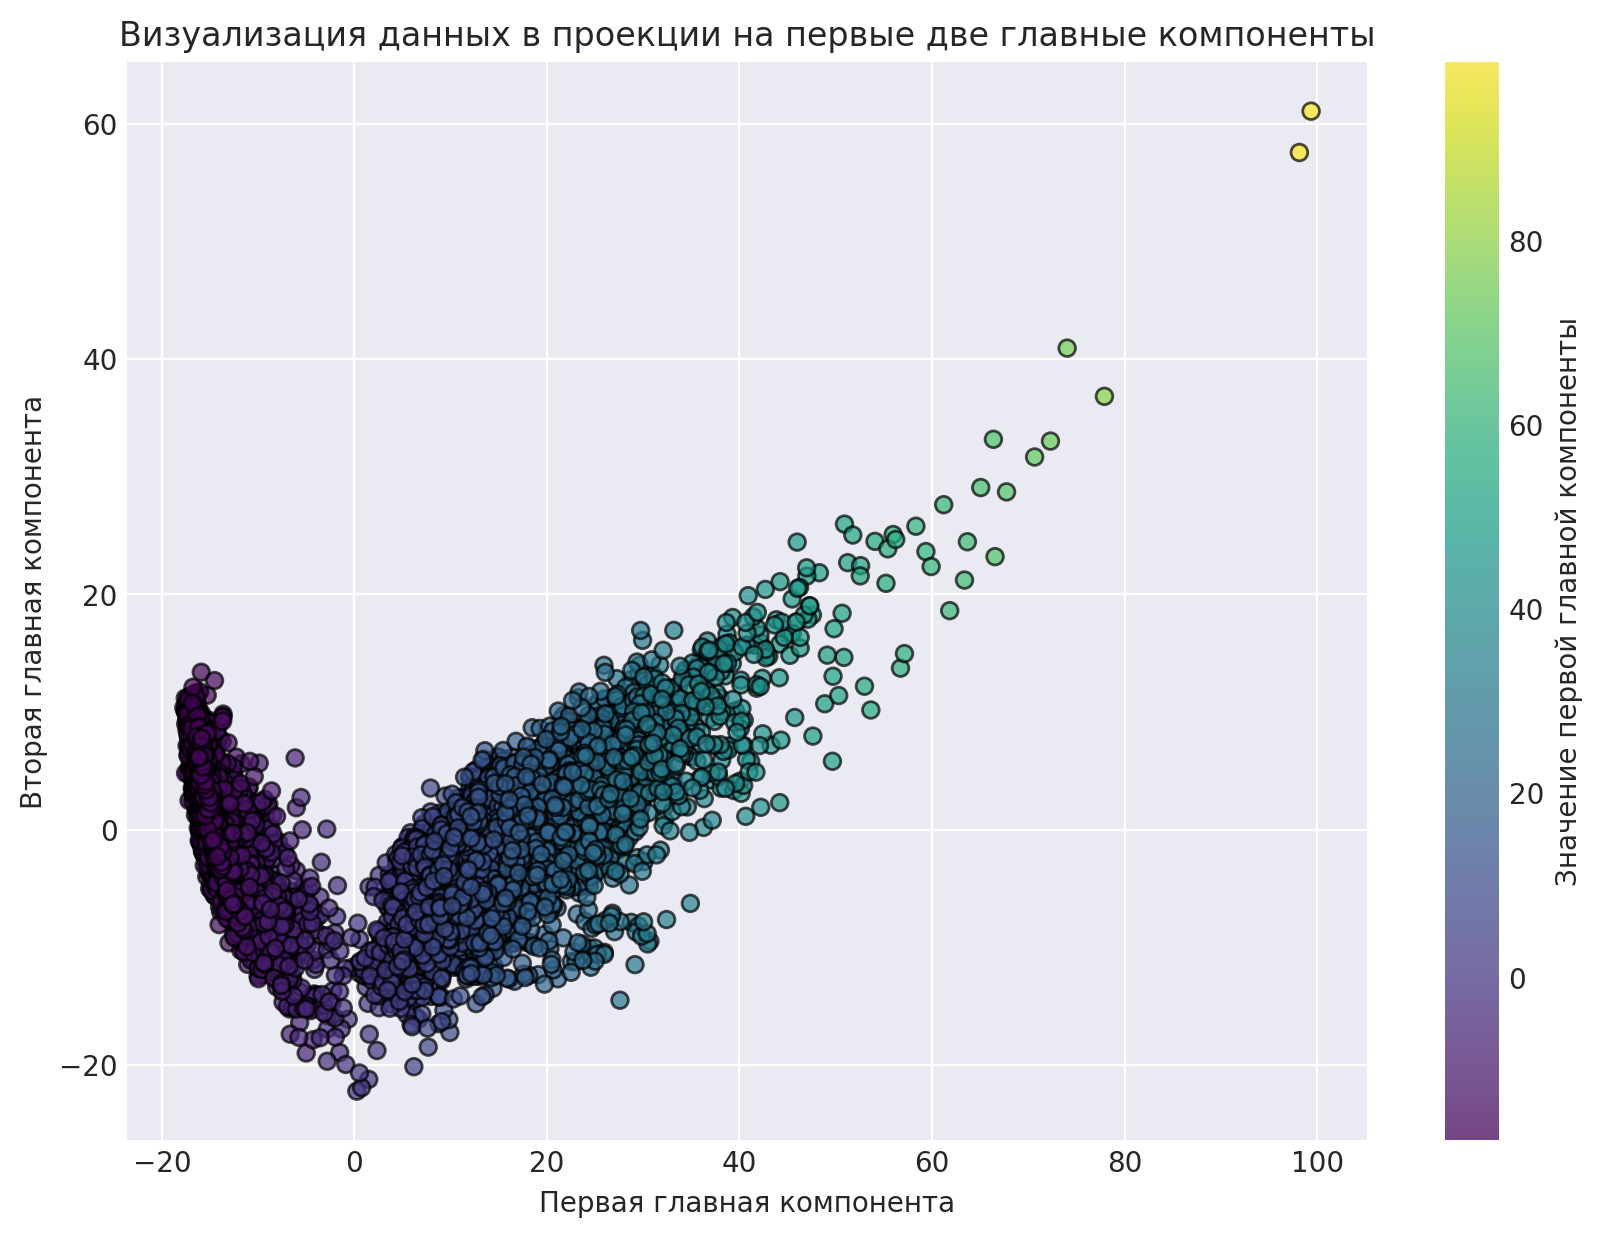

In [ ]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=X_pca[:, 0], cmap="viridis", alpha=0.7, edgecolors="k")

plt.colorbar(scatter, label="Значение первой главной компоненты")

plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.title("Визуализация данных в проекции на первые две главные компоненты")

plt.show()

### **Задание 19. (0.5 балла)**

Разберёмся с `KMeans`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

- Сделайте кластеризацию данных методом `KMeans`, обучив модель на данных со сниженной за счет `PCA` размерностью. Нужно искать 6 кластеров (изначально у нас 6 классов). Засеките время обучения и время инференса.

**Параметры обучения:**

```n_clusters = 6``` (число уникальных меток целевого класса = 6)

```n_init = 100```

```random_state = RANDOM_STATE``` (для воспроизводимости результата, не забывайте указывать его и дальше!)

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
%%time
kmeans = KMeans(n_clusters=6, n_init=100, random_state=RANDOM_STATE)
kmeans.fit(X_pca)

CPU times: user 11.7 s, sys: 7.16 s, total: 18.9 s
Wall time: 13.8 s


KMeans(n_clusters=6, n_init=100, random_state=42)

In [ ]:
%%time
pred_kmeans = kmeans.predict(X_pca)

CPU times: user 8.72 ms, sys: 567 µs, total: 9.29 ms
Wall time: 9.78 ms


### **Задание 20 (0.2 балла)**

- Визуализируйте данные в проекции на первые две главные компоненты.
- Раскрасьте точки в соответствии с полученными метками кластеров.

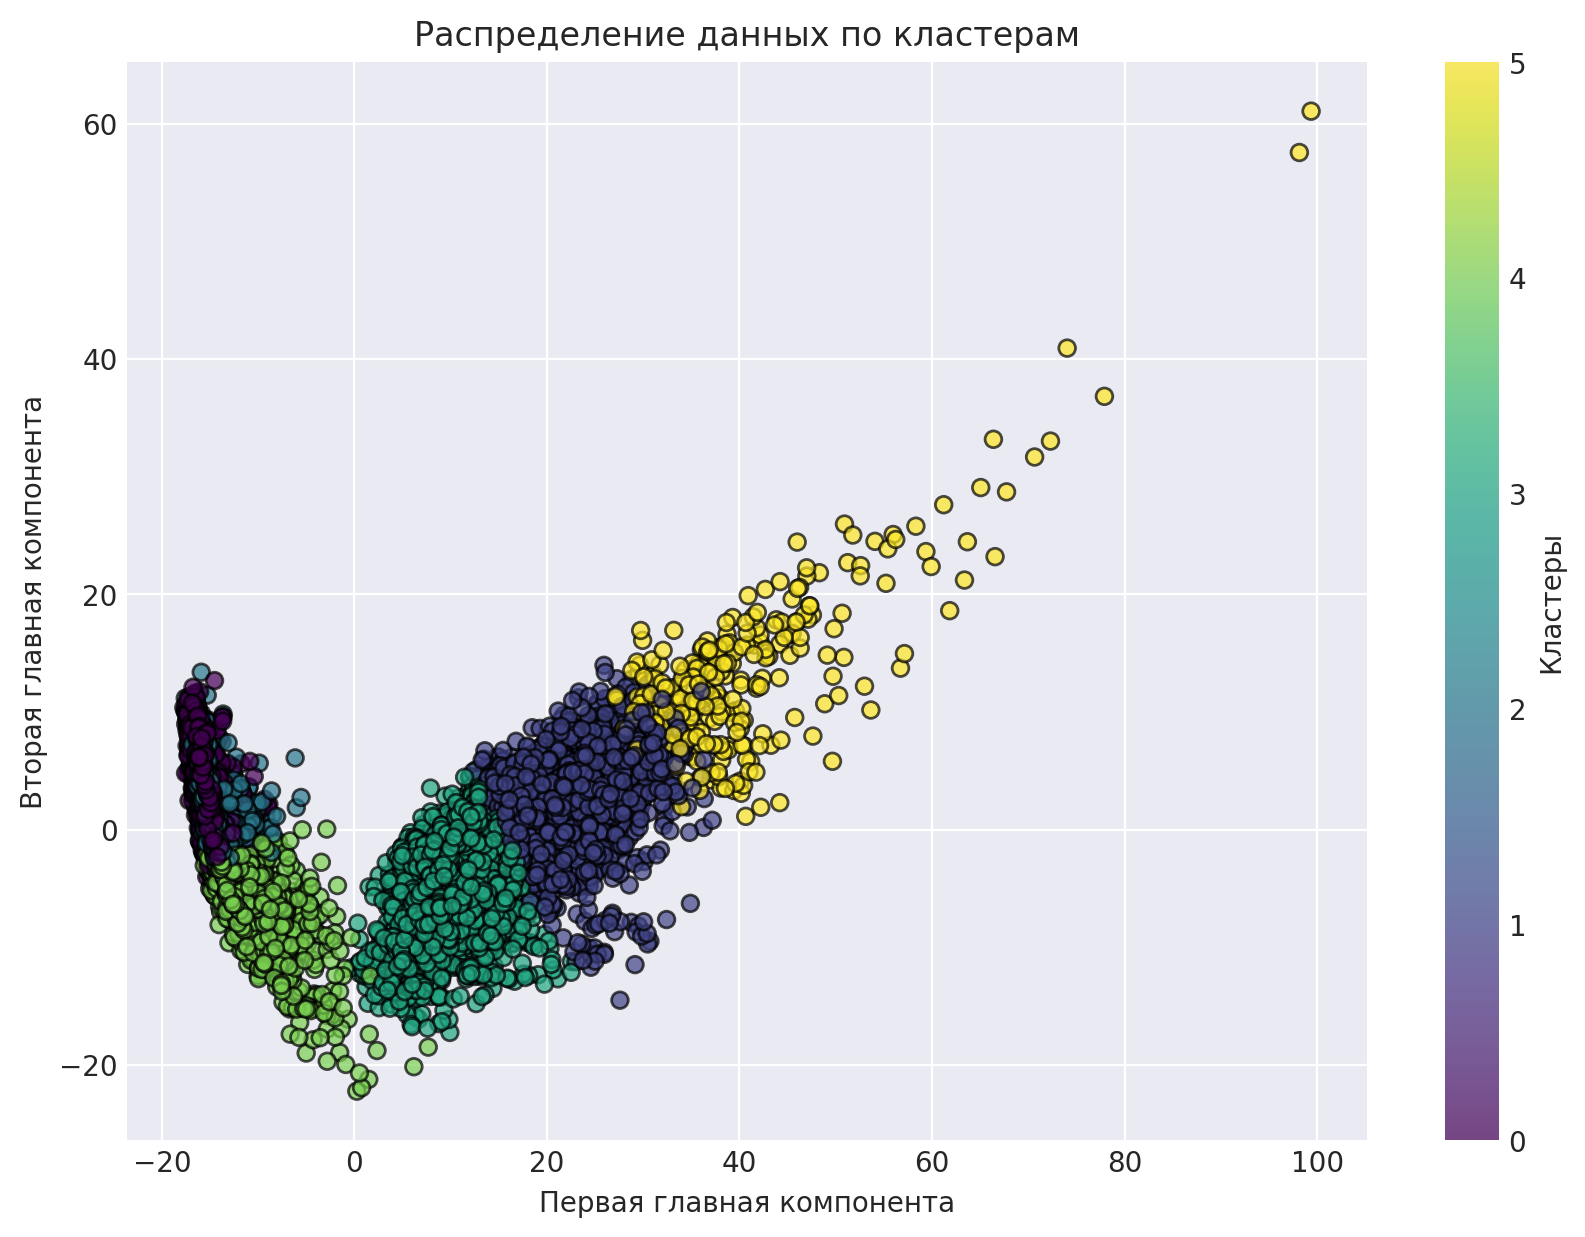

In [ ]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pred_kmeans, cmap="viridis", alpha=0.7, edgecolors="k")

plt.colorbar(scatter, label="Кластеры")

plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.title("Распределение данных по кластерам")

plt.show()

### **Задание 21 (0.3 балла)**

- Выберите какие-то метрики (минимум две) из известных вам. Объясните свой выбор
- Выведите на экран значения метрик качества, сделайте вывод о них и используйте их далее.

In [ ]:
y.shape

(10299, 1)

In [ ]:
y = y.values.ravel()

In [ ]:
y

array([5, 5, 5, ..., 2, 2, 2])

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(y, pred_kmeans)
nmi = normalized_mutual_info_score(y, pred_kmeans)

ari, nmi

(0.4194956465790897, 0.5600410921019028)

ARI - измеряет схожесть предсказанных кластеров с истинными метками. 0.42 довольно слабый результат.  
NMI - насколько структура кластеров отражает реальную структуру классов, 0.56 - кластеры не полностью совпадают с реальными классами.

### **Задание 22 (0.7 баллов)**

Теперь попробуем сделать кластеризацию с помощью `AgglomerativeClustering`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

- Засеките время обучения и время инференса. После кластеризации также:
  - Вновь визуализируйте данные с раскраской по полученным меткам
  - Выведите метрики. Засеките время обучения и время инференса. Сравните с ```KMeans```.

Ответьте на следующие вопросы:
* Стало ли лучше?
* Почему?

In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
%%time
agg_clustering = AgglomerativeClustering(n_clusters=6)
pred_agg = agg_clustering.fit_predict(X_pca)

CPU times: user 11.3 s, sys: 937 ms, total: 12.2 s
Wall time: 15.2 s


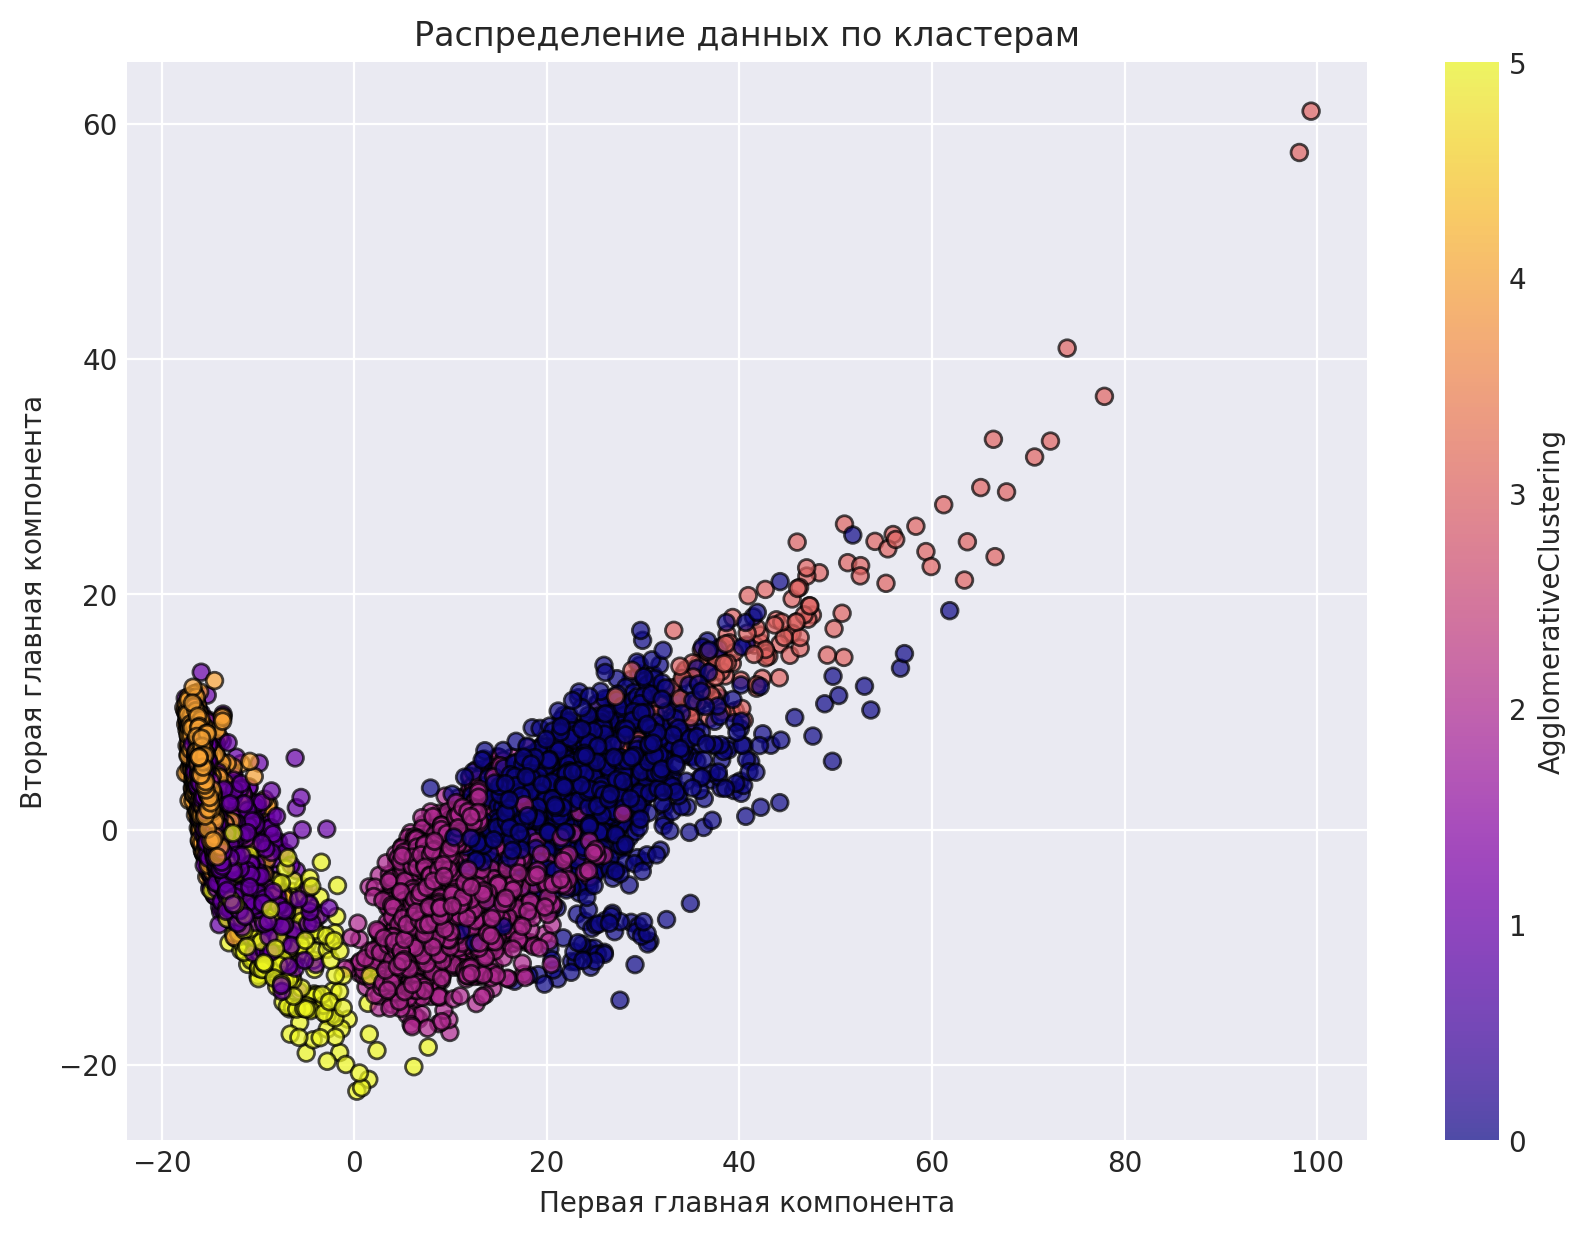

In [ ]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pred_agg, cmap="plasma", alpha=0.7, edgecolors="k")

plt.colorbar(scatter, label="AgglomerativeClustering")

plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.title("Распределение данных по кластерам")

plt.show()

In [ ]:
ari_agg = adjusted_rand_score(y, pred_agg)
nmi_agg = normalized_mutual_info_score(y, pred_agg)
ari_agg, nmi_agg

(0.49362763373004886, 0.6217855076000529)

У kmeans были метрики ari, nmi (0.4194956465790897, 0.5600410921019028), а у AgglomerativeClustering - (0.49362763373004886, 0.6217855076000529), что кажется улучшением более чем на 10%. Не знаю, хороший это прирост или нет, но прирост-таки есть.